# 02 — Exploratory Data Analysis (EDA)
## Peramalan Nilai PM2.5 Harian DKI Jakarta dengan SVR



## 1. Setup dan Muat Data

In [1]:
import os

if 'google.colab' in str(get_ipython()) and not os.path.exists('data'):
    !git clone https://github.com/YudhaAlfarizi/jakarta-pm25-svr-forecasting.git
    %cd jakarta-pm25-svr-forecasting

Cloning into 'jakarta-pm25-svr-forecasting'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 134 (delta 55), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 709.60 KiB | 2.04 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/jakarta-pm25-svr-forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 150)

IN_PATH = 'data/pm25_daily.csv'

In [3]:
df = pd.read_csv(IN_PATH, parse_dates=['tanggal']).set_index('tanggal')
df = df.asfreq('D')  # frekuensi harian eksplisit untuk STL/ACF

print(f"Jumlah baris : {len(df):,}")
print(f"Rentang      : {df.index.min().date()} s.d. {df.index.max().date()}")
print(f"Missing pm25 : {df['pm25'].isna().sum()}")
df.head()

Jumlah baris : 1,520
Rentang      : 2021-01-01 s.d. 2025-02-28
Missing pm25 : 0


,pm25,pm10,so2,co,o3,no2
tanggal,,,,,,
2021-01-01,58.0,38.0,2.0,11.0,65.0,6.0
2021-01-02,86.0,58.0,15.0,22.0,38.0,5.0
2021-01-03,93.0,64.0,14.0,20.0,35.0,5.0
2021-01-04,49.0,30.0,14.5,9.0,77.0,7.0
2021-01-05,89.0,59.0,15.0,19.0,42.0,7.0


## 2. Statistik Deskriptif dan Distribusi

Melihat rentang nilai, kecenderungan pusat, dan apakah distribusinya miring (skewed) atau ada outlier.

In [4]:
print(df['pm25'].describe().round(2))
print(f"\nSkewness: {df['pm25'].skew():.2f}")
print(f"Kurtosis: {df['pm25'].kurt():.2f}")

count    1520.00
mean       89.78
std        26.70
min        10.00
25%        71.00
50%        90.00
75%       107.00
max       287.00
Name: pm25, dtype: float64

Skewness: 0.54
Kurtosis: 2.77


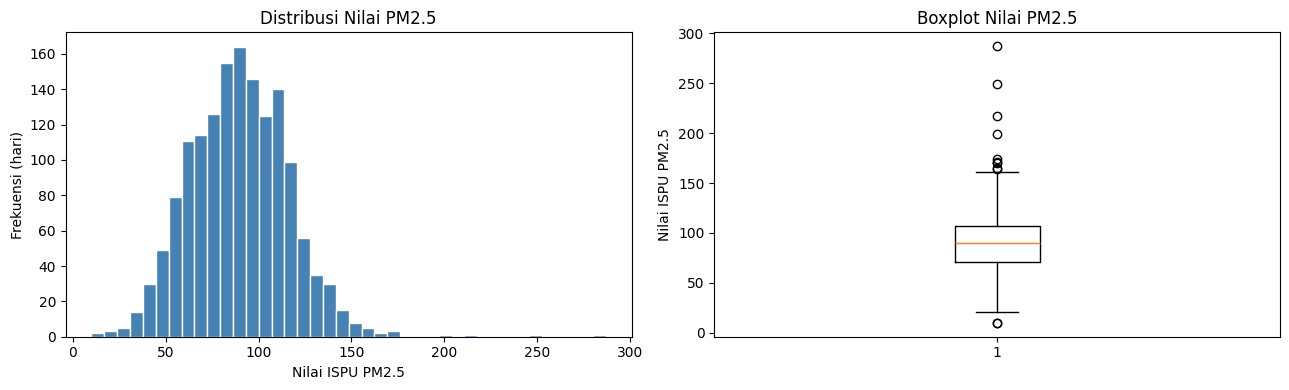

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['pm25'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Nilai PM2.5')
axes[0].set_xlabel('Nilai ISPU PM2.5')
axes[0].set_ylabel('Frekuensi (hari)')

axes[1].boxplot(df['pm25'].dropna(), vert=True)
axes[1].set_title('Boxplot Nilai PM2.5')
axes[1].set_ylabel('Nilai ISPU PM2.5')

plt.tight_layout()
plt.savefig('docs/pm25_distribusi.png', dpi=120)
plt.show()

## 3. Plot Deret Waktu Penuh

Melihat pola keseluruhan: tren, lonjakan, dan periode data hilang.

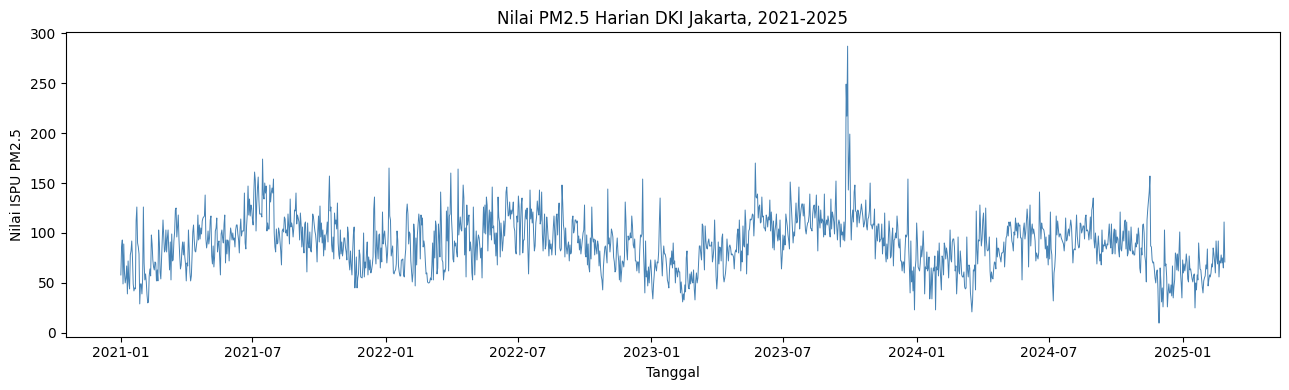

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['pm25'], linewidth=0.7, color='steelblue')
ax.set_title('Nilai PM2.5 Harian DKI Jakarta, 2021-2025')
ax.set_ylabel('Nilai ISPU PM2.5')
ax.set_xlabel('Tanggal')
plt.tight_layout()
plt.savefig('docs/pm25_trend.png', dpi=120)
plt.show()

## 4. Pola Musiman

### 4.1 Rata-rata per bulan

        mean   std
bulan             
1       69.2  22.0
2       70.3  20.6
3       80.1  24.7
4       87.0  21.9
5       98.9  19.8
6      104.2  18.2
7      111.3  24.0
8      104.8  16.1
9      102.5  29.6
10      98.8  22.8
11      83.3  24.0
12      75.1  24.7


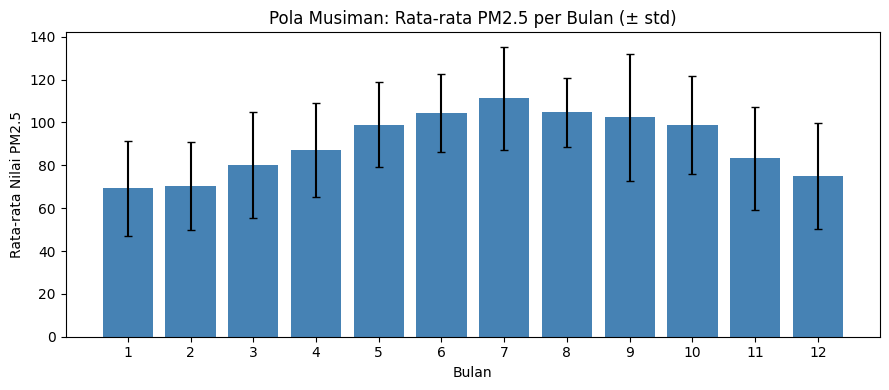

In [7]:
rata_bulanan = df.groupby(df.index.month)['pm25'].agg(['mean', 'std']).round(1)
rata_bulanan.index.name = 'bulan'
print(rata_bulanan)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rata_bulanan.index, rata_bulanan['mean'], yerr=rata_bulanan['std'],
       color='steelblue', capsize=3)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata Nilai PM2.5')
ax.set_title('Pola Musiman: Rata-rata PM2.5 per Bulan (± std)')
plt.tight_layout()
plt.savefig('docs/pm25_pola_bulanan.png', dpi=120)
plt.show()

### 4.2 Rata-rata per hari dalam minggu

Senin     86.9
Selasa    89.9
Rabu      91.6
Kamis     90.8
Jumat     88.4
Sabtu     89.7
Minggu    91.2
Name: pm25, dtype: float64


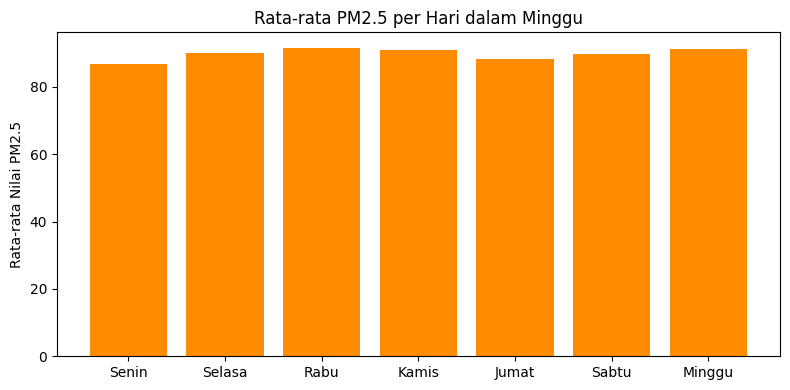

In [8]:
nama_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', "Jumat", 'Sabtu', 'Minggu']
rata_harian = df.groupby(df.index.dayofweek)['pm25'].mean().round(1)
rata_harian.index = nama_hari

print(rata_harian)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rata_harian.index, rata_harian.values, color='darkorange')
ax.set_ylabel('Rata-rata Nilai PM2.5')
ax.set_title('Rata-rata PM2.5 per Hari dalam Minggu')
plt.tight_layout()
plt.show()

## 5. Tren Tahunan

Melihat apakah kualitas udara membaik atau memburuk dari tahun ke tahun. Perhatikan bahwa 2021 dan 2025 tidak mencakup satu tahun penuh.

In [9]:
rata_tahunan = df.groupby(df.index.year)['pm25'].agg(['mean', 'std', 'count']).round(1)
rata_tahunan.index.name = 'tahun'
print(rata_tahunan)
print("\nCatatan: 2021 mulai dari Januari (lengkap), 2025 hanya sampai Februari (tidak penuh).")

       mean   std  count
tahun                   
2021   92.3  25.6    365
2022   92.9  24.4    365
2023   95.2  30.6    365
2024   82.8  23.6    366
2025   64.6  14.3     59

Catatan: 2021 mulai dari Januari (lengkap), 2025 hanya sampai Februari (tidak penuh).


## 6. Dekomposisi STL

STL (Seasonal-Trend decomposition using LOESS) memisahkan deret menjadi tiga komponen: tren, musiman, dan residual. Berguna untuk memastikan pola musiman yang terlihat di bagian 4 bukan kebetulan.

Missing value pada `pm25` sudah 0, sehingga STL bisa langsung dipakai tanpa imputasi tambahan.

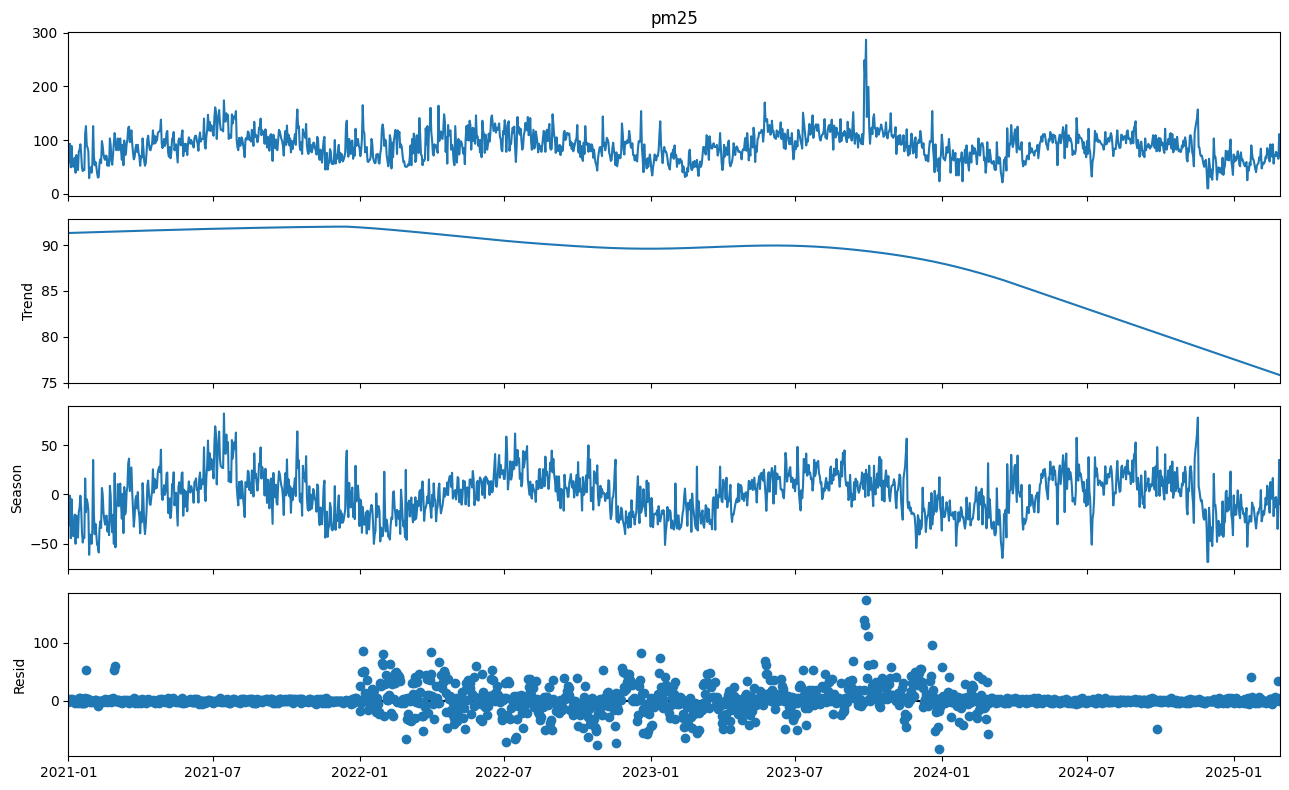

In [10]:
stl = STL(df['pm25'], period=365, robust=True)
hasil_stl = stl.fit()

fig = hasil_stl.plot()
fig.set_size_inches(13, 8)
plt.tight_layout()
plt.savefig('docs/pm25_stl_decomposition.png', dpi=120)
plt.show()

## 7. Uji Stasioneritas (Augmented Dickey-Fuller)

Deret dikatakan stasioner jika rata-rata dan variansnya relatif stabil sepanjang waktu. Hipotesis nol (H0) ADF test: deret **tidak** stasioner (mengandung unit root). Jika p-value < 0.05, H0 ditolak → deret dianggap stasioner.

In [11]:
hasil_adf = adfuller(df['pm25'].dropna())

print(f"ADF Statistic : {hasil_adf[0]:.4f}")
print(f"p-value       : {hasil_adf[1]:.4f}")
print(f"Lags digunakan: {hasil_adf[2]}")
print(f"Jumlah observasi: {hasil_adf[3]}")
print("Critical values:")
for key, val in hasil_adf[4].items():
    print(f"  {key}: {val:.4f}")

if hasil_adf[1] < 0.05:
    print("\nKesimpulan: p-value < 0.05, H0 ditolak → deret PM2.5 dianggap STASIONER.")
else:
    print("\nKesimpulan: p-value >= 0.05, H0 tidak ditolak → deret PM2.5 belum tentu stasioner.")

ADF Statistic : -5.6345
p-value       : 0.0000
Lags digunakan: 9
Jumlah observasi: 1510
Critical values:
  1%: -3.4347
  5%: -2.8635
  10%: -2.5678

Kesimpulan: p-value < 0.05, H0 ditolak → deret PM2.5 dianggap STASIONER.


/tmp/ipykernel_920/2266345508.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil_adf = adfuller(df['pm25'].dropna())


## 8. ACF dan PACF

Ini yang menjadi **dasar pemilihan fitur lag**.

*   ACF menunjukkan korelasi PM2.5 hari ini dengan PM2.5 di lag-lag sebelumnya;
*   PACF menunjukkan korelasi langsung setelah pengaruh lag di antaranya dihilangkan.

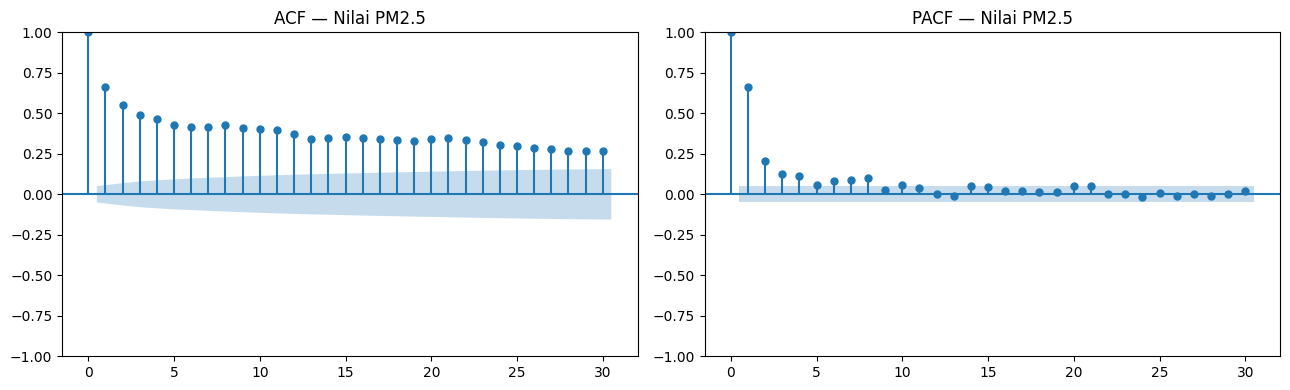

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(df['pm25'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF — Nilai PM2.5')

plot_pacf(df['pm25'].dropna(), lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Nilai PM2.5')

plt.tight_layout()
plt.savefig('docs/pm25_acf_pacf.png', dpi=120)
plt.show()

In [13]:
# Nilai ACF eksak pada lag-lag kandidat yang dipakai di notebook 03
from statsmodels.tsa.stattools import acf

nilai_acf = acf(df['pm25'].dropna(), nlags=14)
print("Nilai ACF pada lag tertentu:")
for lag in [1, 2, 3, 7, 14]:
    print(f"  lag {lag:2d}: {nilai_acf[lag]:.3f}")

Nilai ACF pada lag tertentu:
  lag  1: 0.662
  lag  2: 0.553
  lag  3: 0.492
  lag  7: 0.417
  lag 14: 0.349


**Interpretasi:** Lag dengan ACF yang masih tinggi (mendekati atau di atas ±0.2, di luar pita signifikansi pada grafik) dianggap layak dijadikan fitur. Ini menjustifikasi pemilihan `pm25_lag1`, `pm25_lag2`, `pm25_lag3`, dan `pm25_lag7` di notebook 03 — bukan tebakan sembarangan. Pemilihan fitur final tetap diuji ulang lewat performa model di notebook 04.

## 9. Korelasi dengan Polutan Lain

Menentukan variabel mana yang layak diuji sebagai eksperimen tambahan di `04_svr_modeling.ipynb`.

pm25    1.00
pm10    0.79
co      0.43
o3      0.24
no2     0.07
so2    -0.07
Name: pm25, dtype: float64


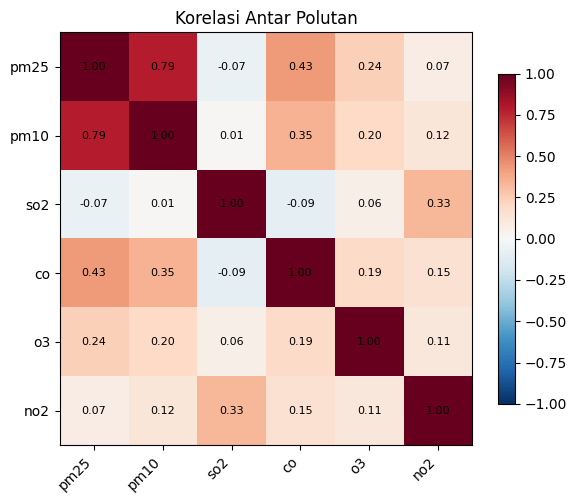

In [14]:
korelasi = df.corr()
print(korelasi['pm25'].round(2).sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(korelasi, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(korelasi.columns)))
ax.set_yticks(range(len(korelasi.columns)))
ax.set_xticklabels(korelasi.columns, rotation=45, ha='right')
ax.set_yticklabels(korelasi.columns)
for i in range(len(korelasi)):
    for j in range(len(korelasi)):
        ax.text(j, i, f"{korelasi.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
ax.set_title('Korelasi Antar Polutan')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('docs/korelasi_polutan.png', dpi=120)
plt.show()

## 10. Ringkasan Temuan

Sel ini mencetak ringkasan otomatis dari semua analisis di atas, untuk disalin ke README atau laporan.

In [15]:
print("=" * 60)
print("RINGKASAN TEMUAN EDA")
print("=" * 60)
print(f"Rentang data       : {df.index.min().date()} s.d. {df.index.max().date()}")
print(f"Rata-rata pm25     : {df['pm25'].mean():.1f}")
print(f"Std pm25           : {df['pm25'].std():.1f}")
print(f"Skewness           : {df['pm25'].skew():.2f}")
print(f"Bulan tertinggi    : {rata_bulanan['mean'].idxmax()} (rata-rata {rata_bulanan['mean'].max():.1f})")
print(f"Bulan terendah     : {rata_bulanan['mean'].idxmin()} (rata-rata {rata_bulanan['mean'].min():.1f})")
print(f"Tahun tertinggi    : {rata_tahunan['mean'].idxmax()} (rata-rata {rata_tahunan['mean'].max():.1f})")
print(f"Tahun terendah     : {rata_tahunan['mean'].idxmin()} (rata-rata {rata_tahunan['mean'].min():.1f})")
print(f"ADF p-value        : {hasil_adf[1]:.4f} ({'stasioner' if hasil_adf[1] < 0.05 else 'belum tentu stasioner'})")
print(f"ACF lag 1          : {nilai_acf[1]:.3f}")
print(f"ACF lag 7          : {nilai_acf[7]:.3f}")
print(f"Korelasi dgn pm10  : {korelasi.loc['pm10', 'pm25']:.2f}")
print(f"Korelasi dgn co    : {korelasi.loc['co', 'pm25']:.2f}")
print(f"Korelasi dgn o3    : {korelasi.loc['o3', 'pm25']:.2f}")
print("=" * 60)

RINGKASAN TEMUAN EDA
Rentang data       : 2021-01-01 s.d. 2025-02-28
Rata-rata pm25     : 89.8
Std pm25           : 26.7
Skewness           : 0.54
Bulan tertinggi    : 7 (rata-rata 111.3)
Bulan terendah     : 1 (rata-rata 69.2)
Tahun tertinggi    : 2023 (rata-rata 95.2)
Tahun terendah     : 2025 (rata-rata 64.6)
ADF p-value        : 0.0000 (stasioner)
ACF lag 1          : 0.662
ACF lag 7          : 0.417
Korelasi dgn pm10  : 0.79
Korelasi dgn co    : 0.43
Korelasi dgn o3    : 0.24


## Ringkasan

| Aspek | Temuan (lihat output Sel 10 untuk angka pasti) |
|---|---|
| Distribusi | Dicetak otomatis (skewness, rentang) |
| Pola musiman | Grafik `docs/pm25_pola_bulanan.png` |
| Tren tahunan | Tabel pada Sel 12 |
| Stasioneritas | Hasil ADF test pada Sel 15 |
| Lag yang relevan | Ditentukan dari ACF/PACF pada Sel 17-18 |
| Polutan paling berkorelasi | `docs/korelasi_polutan.png` |

**Tidak ada file CSV baru dari notebook ini** — hanya analisis dan gambar. Notebook `03_feature_engineering.ipynb` tetap membaca `data/pm25_daily.csv` yang sama.

**Langkah berikutnya:** buka `03_feature_engineering.ipynb` untuk membentuk fitur lag/rolling dan membagi data latih/uji.